# Weather Trends per decade
In this Jupyter notebook, we will analyse the UK Met Office weather data. We will visualise the trends through the decades to see how the weather is changing.

In [1]:
# packages
from calculate_trends import calc_monthly_attribute_per_decade, calc_min_max_per_decade
from clean import create_table
from location import Location
from location_attr import LocationAttributes
from visualisation import create_line_graph

## Choose a location
First we will choose a location. If you would like to know what locations there are to choose from, either look at location.py or start writing "Location."and press "ctrl + space" which will show you a list of all weather stations around the UK.

In [2]:
# location variables
LOCATION = Location.HEATHROW
location_attributes = LocationAttributes(LOCATION)

# data frame
location_attributes.df = create_table(
    location_name=LOCATION.value, location_url=location_attributes.url, data_refresh=False
)


## Look into weather trends
Now we have a clean weather dataset, we can now look into the trends through different time periods in the location specified above.

### Maximum Temperatures each MMonth by Decase
We will visualise the Maximum temperatures per decade for each month

In [3]:
# find average monthly maximum temperature by decade
df_avg_month_by_decade = calc_monthly_attribute_per_decade(
    location_attributes.df, "tmax_degC", month_col="worded_month", aggregate_func="max"
)

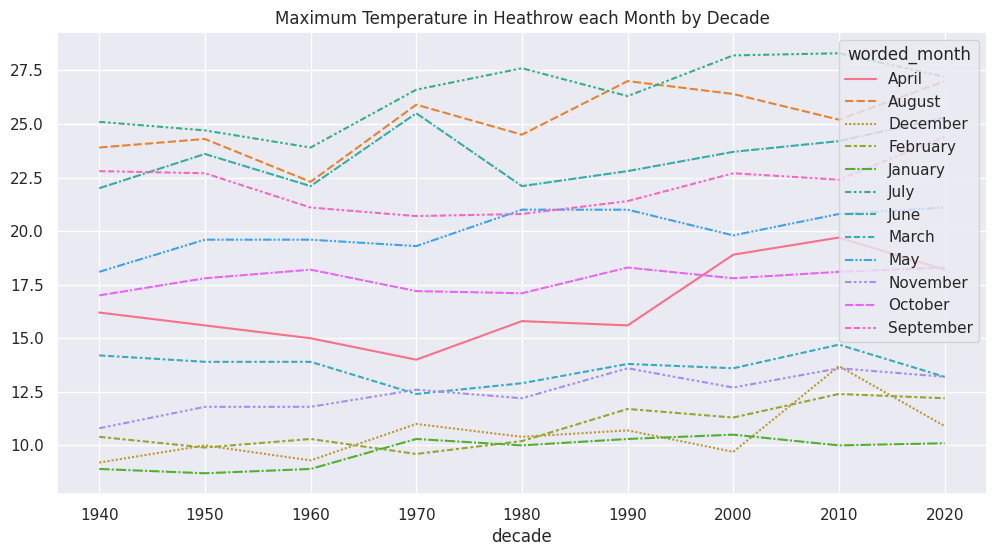

In [4]:
# visualisation
create_line_graph(
    df_avg_month_by_decade,
    title= f"Maximum Temperature in {LOCATION.value.title()} each Month by Decade"
)

### Maximum and minimum temperatures per decade for a specified month

In [5]:
# find minimum and maximum monthly temperature by decade
df_min_max = calc_min_max_per_decade(location_attributes.df, month_col="worded_month")

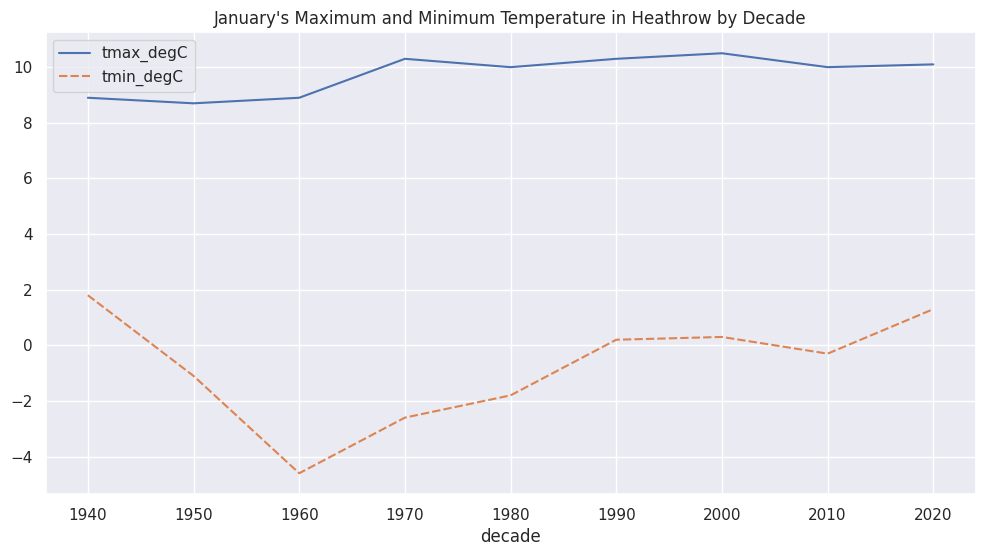

In [6]:
month_to_graph = "January"
create_line_graph(
    df_min_max,
    is_min_max=True,
    col_x="decade",
    col_y=month_to_graph,
    title= f"{month_to_graph}'s Maximum and Minimum Temperature in {LOCATION.value.title()} by Decade"
)

### Sum of Rainfall per month by decade

In [7]:
# rainfall during the decades
df_rainfall = calc_monthly_attribute_per_decade(
    location_attributes.df, "rain_mm", month_col="worded_month", aggregate_func="sum",
)

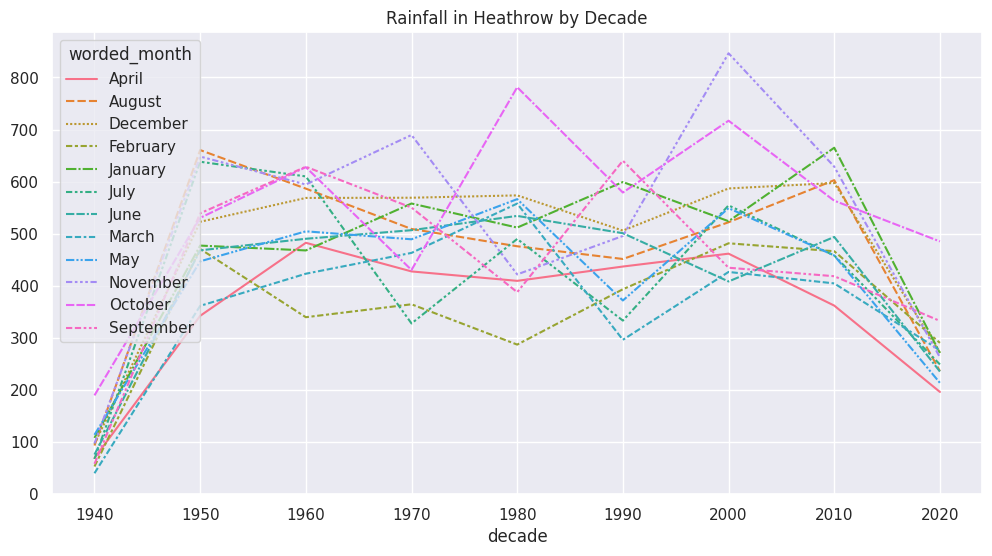

In [8]:

create_line_graph(
    df_rainfall,
    title= f"Rainfall in {LOCATION.value.title()} by Decade"
)